         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

/tmp/ipython-input-2302124918.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="diagnosis", data=df, palette="magma")


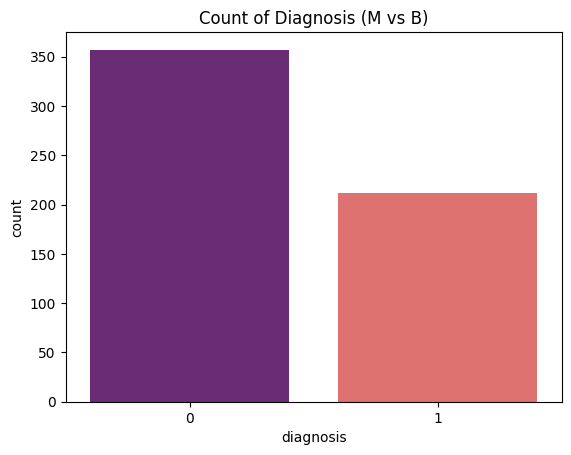

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data.csv")

print(df.head())

df.info()

print(df.isnull().sum())

df["diagnosis"] = df["diagnosis"].astype(str).str.strip().str.upper().map({"M":1, "B":0})

df = df.drop(columns=["Unnamed: 32"])
# df = df.dropna(subset=["diagnosis"])

X =df.drop("diagnosis", axis=1)
y = df["diagnosis"]

sns.countplot(x="diagnosis", data=df, palette="magma")
plt.title("Count of Diagnosis (M vs B)")
plt.show()

In [3]:
# counting unique rows in diagnosis
print(df["diagnosis"].value_counts())

# Mapping categorical to numeric (M=1, B=0)
# df["diagnosis"] = df["diagnosis"].map({"M":1, "B":0})

# Featires (X) and target (y)
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

diagnosis
0    357
1    212
Name: count, dtype: int64


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

# SVM
# Scale features on TRAIN only, then apply to TEST
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # learn μ,σ on train and transform
X_test_scaled  = scaler.transform(X_test)        # use same μ,σ on test

# Fit SVM on the *scaled* data
svm = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)
print("Support Vector Machine Accuracy:", accuracy_score(y_test, y_pred_svm))

Logistic Regression Accuracy: 0.956140350877193
KNN Accuracy: 0.7543859649122807
Random Forest Accuracy: 0.9649122807017544
Support Vector Machine Accuracy: 0.9824561403508771


In [12]:
accuracies = {
    "Logistic Regression": accuracy_score(y_test, y_pred_log),
    "KNN": accuracy_score(y_test, y_pred_knn),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "SVM": accuracy_score(y_test, y_pred_svm),
}

best_model = max(accuracies, key=accuracies.get)
print("\nBest model is:", best_model, "with accuracy:", accuracies[best_model])


Best model is: SVM with accuracy: 0.9824561403508771
